<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [66]:
'''Code pour ignorer les warning
import warnings
warnings.simplefilter("ignore")'''

'Code pour ignorer les warning\nimport warnings\nwarnings.simplefilter("ignore")'

In [67]:
#Importation de la librairie Pandas
import pandas as pd

In [68]:
#Importation de la librairie plotly express
import plotly.express as px

In [69]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots cles "display all columns dataframe Pandas", par exemple
#Dans les resultats de la recherche, privilegiez les solutions provenants de Stack Overflow ou Medium

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [70]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [71]:
#Afficher les dimensions du dataset
df_erp.info()
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))
#La nature des donnees dans chacune des colonnes
type(df_erp)
#Le nombre de valeurs (observations, caracteristiques) presentes dans chacune des colonnes
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB
Le tableau comporte 6 colonne(s)
Le tableau comporte 825 observation(s) ou article(s)


In [72]:
#Afficher les 5 premieres lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [73]:
#Verifier si il y a les lignes en doublons dans la colonne product_id
#Utiliser drop_duplicates() pour supprimer le lignes en doublons
unique_df = df_erp.drop_duplicates()
unique_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [74]:
#Afficher les valeurs distinctes de la colonne stock_status
#A quelle(s) autre(s) colonne(s) sont-elles liees ?
'''Elles sont lies aux a la colonne stock_quantity, si elle est à 0, alors outofstock, sinon instock'''
df_erp.head()
df_erp["stock_status"].unique()

array(['instock', 'outofstock'], dtype=object)

In [75]:
#Creation d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(lambda x: "instock" if x > 0 else "outofstock" )

In [76]:
#Verifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 a 2
#La comparaison de 2 colonnes peut se realiser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]
'''Le resultat est l'affichage de True ou False pour chacune des lignes du dataset, c'est un bon debut, mais difficile à exploiter'''

"Le resultat est l'affichage de True ou False pour chacune des lignes du dataset, c'est un bon debut, mais difficile à exploiter"

In [77]:
#Mais il est possible de synthetiser ce resultat en effectuant la somme de cette colonne :
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

np.int64(823)

In [78]:
#Si les colonnes ne sont absolument pas identiques ligne a ligne alors identifier la ligne en ecart
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]
'''2 lignes erreurs -> 4 et 398'''
#Dans ce cas je vous ce lien pour apprendre a realiser des filtres dans Pandas : https://bitbucket.org/hrojas/learn-pandas/src/master/ (Lesson 3)

'2 lignes erreurs -> 4 et 398'

In [79]:
#Corriger la ou les donnees incoherentes
df_erp.loc[df_erp["product_id"]==4039, "stock_status"] = "instock"
df_erp.loc[df_erp["product_id"]==4885, "stock_status"] = "outofstock"
#Verification en utilisant le meme code que plus haut pour afficher les problemes
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [80]:
###############
## LES PRIX  ##
###############

#Verification des prix: Y a t-il des prix non renseignes, negatif ou nul?
#Afficher le ou les prix non renseignes dans la colonne "price"
a = df_erp[df_erp["price"] <= 0]
print(a)
'''print("Nombres d'article avec un prix non renseignes: {}".format()) #Saisir l'instruction manquante dans la fonction format'''
#Afficher le prix minimum de la colonne "price"
b = df_erp["price"].min()
print(b)
#Afficher le prix maximum de la colonne "price"
c = df_erp["price"].max()
print(c)
#Affichier les prix inferieurs a 0 (qu'est ce qu'il faut en faire ?) -> les supprimer ?
d = df_erp[df_erp["price"] < 0]
print(d)

     product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  
151           10.33     outofstock  
469            4.34     outofstock  
739            4.61        instock  
-20.0
225.0
     product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  
151           10.33     outofstock  
469            4.34     outofstock  
739            4.61        instock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [81]:
#######################
### stock_quantity  ###
#######################

#Verification de la colonne stock quantity
#Afficher la quantite minimum de la colonne "stock_quantity"
a = df_erp["stock_quantity"].min()
print(a)
#Afficher la quantite maximum de la colonne "stock_quantity"
b = df_erp["stock_quantity"].max()
print(b)
#Afficher les stocks inferieurs a 0 (qu'est ce qu'il faut en faire ?) -> les supprimer ?
c = df_erp[df_erp["stock_quantity"] < 0]
print(c)

-10
145
     product_id  onsale_web  price  stock_quantity stock_status  \
449        4973           0   10.0             -10   outofstock   
573        5700           1   44.5              -1   outofstock   

     purchase_price stock_status_2  
449            4.96     outofstock  
573           22.30     outofstock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [82]:
#Verification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?
df_erp["onsale_web"].unique()
#Est-ce vendu sur le web: 1->oui et 0->non

array([1, 0])

In [83]:
#Quelles sont les colonnes a conserver selon vous?
'''Toute sauf stock_status2" -> faire attention a ne pas supprimer plusieurs fois la colonne'''

'Toute sauf stock_status2" -> faire attention a ne pas supprimer plusieurs fois la colonne'

In [84]:
#Supprimer la colonne comportant le libelle "stock_status_2" car elle est redondante avec la colonne "stock_status" -> voir au dessus
df_erp.drop(['stock_status_2'], axis=1, inplace=True)
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [85]:
######################
##   prix d'achat   ##
######################

#Verification de la colonne purchase_price :
#Afficher le ou les prix non renseignes dans la colonne "purchase_price"
df_erp[df_erp["purchase_price"] <= 0]
#Afficher le prix minimum de la colonne "purchase_price"
df_erp["purchase_price"].min()
#Afficher le prix maximum de la colonne "purchase_price"
df_erp["purchase_price"].max()

137.81

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [86]:
#Dimension du dataset
df_web.info()
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))
#La nature des donnees dans chacune des colonnes
type(df_web)
#Le nombre de valeurs (observations, caracteristiques) presentes dans chacune des colonnes
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [87]:
#Selon vous, quelles sont les colonnes a conserver ?
'''Toute celles qui ne sont pas a 0 (donnees)'''
liste_colonnes = ["tax_class", "post_content", "post_password", "post_content_filtered"]
for col in liste_colonnes:
    df_web.drop(col, axis=1, inplace=True)

In [88]:
#Si vous avez defini des colonnes a supprimer, effectuer l'operation
'''Celle n'ayant pas de liens avec le prix
df_web.drop(df_web['ping_status'], axis=1, inplace=True)'''

"Celle n'ayant pas de liens avec le prix\ndf_web.drop(df_web['ping_status'], axis=1, inplace=True)"

In [89]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la regle de codification?
df_web['sku'].unique()

array([11862, 16057, 14692, 16295, 15328, 15471, 16515, 16246, nan, 13572,
       16513, 16585, 16269, 15526, 12869, 15575, 11586, 14338, 15425,
       16560, 15361, 13809, 11587, 15022, 14323, 16342, 16029, 15475,
       13754, 14680, 15875, 9636, 13849, 13662, 16564, 13557, 15429,
       14712, 15032, 15481, 15448, 16580, 15441, 804, 15300, 13958, 16071,
       15678, 13895, 15711, 12882, 16053, 13766, 16247, 12640, 15292,
       15476, 15670, 16189, 16038, 14864, 16044, 15324, 15531, 15953,
       15413, 15733, 14366, 15895, 15892, 16472, 15185, 16010, 15793,
       15849, 12315, 15741, 15934, 15148, 15781, 15659, 15106, 15490,
       14507, 14149, 16307, 13736, 14090, 16037, 15758, 14661, 12587,
       15337, 15489, 15201, 16305, 16131, 13435, 15747, 12203, 14509,
       14768, 16262, 14561, 16505, 15717, 16129, 13460, 15871, 15940,
       11602, 13127, 13520, 15480, 13032, 15436, 15269, 15910, 19821,
       16263, 15138, 15146, 15126, 15482, 16186, 13905, 16540, 15856,
       1567

In [90]:
#Si vous avez identifie des codes articles ne respectant pas la regle de codification, consultez-les?
'''sku -> code barre'''
df_web.head(20)

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,...,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,...,closed,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,...,closed,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,...,closed,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,...,closed,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,...,closed,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
5,15471,0,0,0,0.0,4.0,NaN,2.0,2019-03-19 15:58:25,2019-03-19 14:58:25,...,closed,arcole-saint-emilion-grand-cru-2016,2020-06-18 10:45:05,2020-06-18 08:45:05,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
6,16515,0,0,0,0.0,10.0,taxable,2.0,2018-06-02 09:31:31,2018-06-02 07:31:31,...,closed,chateau-turcaud-bordeaux-rouge-cuvee-majeure-2018,2020-08-27 10:11:12,2020-08-27 08:11:12,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
7,16246,0,0,0,0.0,10.0,NaN,2.0,2018-02-28 14:46:15,2018-02-28 13:46:15,...,closed,la-tour-du-bon-bandol-blanc-2019,2020-08-26 15:55:03,2020-08-26 13:55:03,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
9,13572,0,0,0,0.0,17.0,NaN,2.0,2019-03-19 11:33:39,2019-03-19 10:33:39,...,closed,tour-haut-caussan-medoc-2015,2020-08-26 16:55:02,2020-08-26 14:55:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0


In [91]:
#Identifier les lignes sans code articles
df_web[df_web["sku"] == "13127-1"]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,...,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
272,13127-1,0,0,0,0.0,4.0,taxable,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,...,closed,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1117,13127-1,0,0,0,0.0,4.0,NaN,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,...,closed,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0


In [92]:
df_web[df_web["sku"].isnull()]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,...,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
df_web[df_web["sku"] == "bon-cadeau-25-euros"]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,...,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
842,bon-cadeau-25-euros,0,0,0,0.0,7.0,NaN,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,...,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,...,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [94]:
df_web = df_web[df_web["post_type"] == "product"]
'''On supprime tout les attachements'''
df_web.info()

<class 'pandas.core.frame.DataFrame'>
Index: 716 entries, 2 to 1509
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                714 non-null    object        
 1   virtual            716 non-null    int64         
 2   downloadable       716 non-null    int64         
 3   rating_count       716 non-null    int64         
 4   average_rating     716 non-null    float64       
 5   total_sales        716 non-null    float64       
 6   tax_status         716 non-null    object        
 7   post_author        716 non-null    float64       
 8   post_date          716 non-null    datetime64[ns]
 9   post_date_gmt      716 non-null    datetime64[ns]
 10  product_type       715 non-null    object        
 11  post_title         716 non-null    object        
 12  post_excerpt       716 non-null    object        
 13  post_status        716 non-null    object        
 14  comment_status

In [95]:
#Pour les codes articles identifies, realisez une analyse et definissez l'action a entreprendre
df_web[df_web["sku"].isnull()].info()
''' Et on supprime tout ceux etant Null'''
df_web = df_web[df_web["sku"].notnull()]

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 1084 to 1087
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            2 non-null      int64         
 2   downloadable       2 non-null      int64         
 3   rating_count       2 non-null      int64         
 4   average_rating     2 non-null      float64       
 5   total_sales        2 non-null      float64       
 6   tax_status         2 non-null      object        
 7   post_author        2 non-null      float64       
 8   post_date          2 non-null      datetime64[ns]
 9   post_date_gmt      2 non-null      datetime64[ns]
 10  product_type       2 non-null      object        
 11  post_title         2 non-null      object        
 12  post_excerpt       2 non-null      object        
 13  post_status        2 non-null      object        
 14  comment_statu

In [96]:
#La cle pour chaque ligne est-elle uniques ? Ou autrement dit, y a-t-il des doublons ?
'''Cle unique pas unique (duplication) + beaucoup de Null'''
df_web[df_web["sku"].isnull()][df_web["total_sales"].notnull()]

<ipython-input-96-e256754877f2>:3: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,...,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count


In [97]:
#Les lignes sans code article semble être toutes non renseignes
#Pour s'en assurer realiser les etapes suivantes:
#1 - Creer un dataframe avec uniquement les lignes sans code article

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
df_web.info()
#3 - Que constatez-vous ?
df_web.loc[1084, "sku"] = "produit_inconnu_0"
df_web.loc[1087, "sku"] = "produit_inconnu_1"

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                714 non-null    object        
 1   virtual            714 non-null    int64         
 2   downloadable       714 non-null    int64         
 3   rating_count       714 non-null    int64         
 4   average_rating     714 non-null    float64       
 5   total_sales        714 non-null    float64       
 6   tax_status         714 non-null    object        
 7   post_author        714 non-null    float64       
 8   post_date          714 non-null    datetime64[ns]
 9   post_date_gmt      714 non-null    datetime64[ns]
 10  product_type       713 non-null    object        
 11  post_title         714 non-null    object        
 12  post_excerpt       714 non-null    object        
 13  post_status        714 non-null    object        
 14  comment_status

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [98]:
#Dimension du dataset
df_liaison.info()
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))
#La nature des donnees dans chacune des colonnes
type(df_liaison)
#Le nombre de valeurs (observations, caracteristiques) presentes dans chacune des colonnes
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB
Le tableau comporte 2 colonne(s)
Le tableau comporte 825 observation(s) ou article(s)


In [99]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques ?
df_liaison.shape[0] == df_liaison["product_id"].unique().size

True

In [100]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques ?
df_liaison.shape[0] == df_liaison["id_web"].unique().size

False

In [101]:
#Avons-nous des articles sans correspondances ?
any(df_liaison["product_id"].isnull())
'''df_liaison[df_liaison["product_id"].isnull() == True].size
df_liaison[df_liaison["id_web"].isnull() == True].size'''

'df_liaison[df_liaison["product_id"].isnull() == True].size\ndf_liaison[df_liaison["id_web"].isnull() == True].size'

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [102]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison, how="outer", on="product_id", indicator=True)

In [103]:
#Avons-nous des lignes sans correspondances ?
'''Colonnes differentes de both -> 2 produits existent mais ne sont pas presents dans la liaison'''
df_merge[df_merge["_merge"] != "both"]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge


In [104]:
df_merge.drop("_merge",axis=1,inplace=True)

In [105]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers ?
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
 6   id_web          734 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 45.2+ KB


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [106]:
#Fusionnez les datasets df_merge et df_web
df_merge = pd.merge(df_merge, df_web, how="outer", left_on="id_web", right_on="sku", indicator=True)

In [107]:
#Avons-nous des lignes sans correspondances ?
'''Colonne differentes de both -> 2 produits existent mais ne sont pas present dans la liaison'''
df_merge[df_merge["_merge"] != "both"]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,...,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge
81,4741.0,0.0,12.4,0.0,outofstock,6.66,12601,NaN,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
127,5957.0,0.0,39.0,0.0,outofstock,20.75,13577,NaN,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
139,4289.0,0.0,22.8,0.0,outofstock,11.90,13771,NaN,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
180,4869.0,0.0,17.2,0.0,outofstock,9.33,14360,NaN,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
185,5955.0,0.0,27.3,0.0,outofstock,13.68,14377,NaN,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,7196.0,0.0,31.0,55.0,instock,31.20,NaN,NaN,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
823,7200.0,0.0,31.0,6.0,instock,15.54,NaN,NaN,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
824,7201.0,0.0,31.0,18.0,instock,16.02,NaN,NaN,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
825,7203.0,0.0,45.0,30.0,instock,23.48,NaN,NaN,NaN,NaN,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [108]:
#On cherche a supprimer _merge
df_merge.drop("_merge",axis=1,inplace=True)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

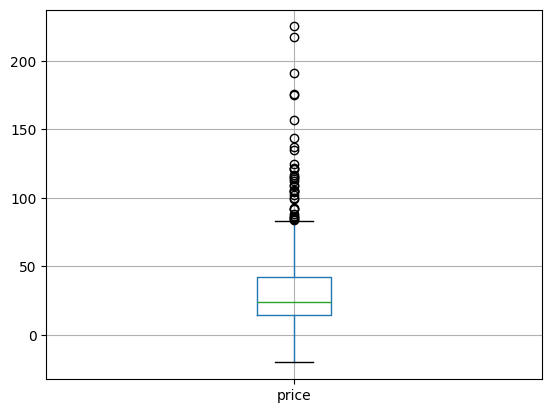

In [109]:
#Creation d'une Boite a moustache de la repartition des prix grace à Pandas
df_merge[["price"]].boxplot()

In [110]:
#Autre methode avec plotly express (Q3*1.5*interquartile pour la limite des valeurs aberrantes)
px.box(data_frame=df_merge,y="price", title ="Repartition des prix")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [111]:
#Calculer la moyenne du prix
moyenne = df_erp["price"].mean()
print(moyenne)
#Calculer l'ecart-type du prix
ecart_type = df_erp["price"].std()
print(ecart_type)
#Calculer le Z-score (=moyenne/ecart-type)
Z_score = moyenne/ecart_type
print(Z_score)

32.187696969696965
26.712076775505285
1.2049866897362609


In [112]:
#Quel est le seuil prix dont z-score est superieur à 3?
'''(chaque_prix-moyenne)/ecart_type=Z_score -> faire avec max et min
A partir de 102.3, les valeurs sont aberrantes'''
df_outliers = df_erp[df_erp["price"].apply(lambda x : (abs(x-moyenne)/ecart_type) > 3)]
df_outliers["price"].min()

114.0

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [113]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
df_erp["price"].describe()

,price
count,825.000000
mean,32.187697
std,26.712077
min,-20.000000
25%,14.500000
50%,24.300000
75%,42.000000
max,225.000000


In [114]:
#Definissez un seuil pour les articles "outliers" en prix
'''Formule du seuil = Q3+(Q3-Q1)*1.5'''
df_describe=df_erp["price"].describe()
seuil = df_describe.loc["75%"] + (df_describe.loc["75%"] - df_describe.loc["25%"])*1.5
print(seuil)

83.25


In [115]:
#Definissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
df_outliers = df_erp[df_erp["price"]>seuil]
print(df_outliers)
proportion = df_outliers.shape[0]/df_erp.shape[0]
print(proportion*100, "%")

     product_id  onsale_web  price  stock_quantity stock_status  \
19         4055           0   86.1               0   outofstock   
66         4115           1  100.0              12      instock   
68         4132           1   88.4               7      instock   
208        4352           1  225.0               0   outofstock   
214        4359           1   85.6             112      instock   
227        4402           1  176.0              11      instock   
228        4404           1  108.5              17      instock   
230        4406           1  157.0              12      instock   
231        4407           1  104.0              14      instock   
240        4582           1  109.6              18      instock   
242        4594           1  144.0               0   outofstock   
410        4903           1  102.3              12      instock   
411        4904           1  137.0               9      instock   
460        5001           1  217.5              18      instoc

In [116]:
#Selon vous, ces outliers sont-ils justifies ? Comment le demontrer si cela est possible ?
'''Oui, car bouteilles de luxe (jointure avec id_web pour trouver le nom des produits)'''

'Oui, car bouteilles de luxe (jointure avec id_web pour trouver le nom des produits)'

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [117]:
##############################
# Calculer le CA su site web #
##############################

#Creez une colonne calculant le CA par article
df_merge["CA"] = df_merge["total_sales"]*df_merge["price"]
df_merge.info()
#Calculez la somme de la colonne "ca_par_article", ce resultat correspond au chiffre d'affaire du site web
CA = df_merge["CA"].sum()
print(CA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 827 entries, 0 to 826
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         825 non-null    float64       
 1   onsale_web         825 non-null    float64       
 2   price              825 non-null    float64       
 3   stock_quantity     825 non-null    float64       
 4   stock_status       825 non-null    object        
 5   purchase_price     825 non-null    float64       
 6   id_web             734 non-null    object        
 7   sku                716 non-null    object        
 8   virtual            714 non-null    float64       
 9   downloadable       714 non-null    float64       
 10  rating_count       714 non-null    float64       
 11  average_rating     714 non-null    float64       
 12  total_sales        714 non-null    float64       
 13  tax_status         714 non-null    object        
 14  post_autho

In [118]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre decroissant du CA du dataset df_merge
df_merge.sort_values("CA", ascending=False, inplace=True)
#Reinitialiser l'index du dataset par un reset_index
df_merge.reset_index(drop=True, inplace=True)
#Afficher les 20 premier articles en CA
df_merge.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
px.bar(data_frame=df_merge[:20][::-1], y="post_title", x="CA", orientation="h", title="CA des 20 premiers articles les plus couteux")

In [119]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Creer une colonne calculant la part du CA de la ligne dans le dataset (remplacer total_sales par CA)
df_merge.sort_values("CA", ascending=False, inplace=True)
df_merge["CA_cumulate"] = df_merge["CA"].cumsum()
#Creer une colonne realisant la somme cumulative de la colonne precedemment creee
df_merge["CA_cumulate%"] = df_merge["CA_cumulate"]/df_merge["CA"].sum()
#Grace au deux colonnes creees precedemment, calculer le nombre d'articles representant 80% du CA
df_merge[df_merge["CA_cumulate%"] <= 0.8].shape[0]
#Afficher la proportion que representent ce groupe d'articles dans le catalogue entier du site web
(df_merge[df_merge["CA_cumulate%"] <= 0.8].shape[0]/df_merge.shape[0])*100

52.4788391777509

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

In [120]:
#####################################
# Palmares des articles en quantite #
#####################################

#Effectuer le tri dans l'ordre decroissant de quantites vendues du dataset df_merge
df_merge.sort_values("total_sales", ascending=False, inplace=True)
#Reinitialiser l'index du dataset par un reset_index
df_merge.reset_index(drop=True, inplace=True)
#Afficher les 20 premier articles en quantite
df_merge.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
px.bar(data_frame=df_merge[:20][::-1], y="post_title", x="total_sales", orientation="h", title="Ventes totales des 20 premiers articles les plus couteux")

In [121]:
###################################
# Calculer le 20 / 80 en quantite #
###################################

#Creer une colonne calculant la part en quantite de la ligne dans le dataset
df_merge.sort_values("total_sales", ascending=False, inplace=True)
df_merge["total_sales_cumulate"] = df_merge["total_sales"].cumsum()
#Creer une colonne realisant la somme cumulative de la colonne precedemment creee
df_merge["total_sales_cumulate%"] = df_merge["total_sales_cumulate"]/df_merge["total_sales"].sum()
#Grace au deux colonnes creees precedemment, calculer le nombre d'articles representant 80% des ventes en quantite
df_merge[df_merge["total_sales_cumulate%"] <= 0.8].shape[0]
#Afficher la proportion que representent ce groupe d'articles dans le catalogue entier du site web
(df_merge[df_merge["total_sales_cumulate%"] <= 0.8].shape[0]/df_merge.shape[0])*100

52.35792019347038

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [122]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np
#Creation de la colonne Rotation de stock (quantite/nombre de vente)
df_merge["rotation_stock"] = df_merge["stock_quantity"]/df_merge["total_sales"]
#Remplacement des "inf" par 0
df_merge["rotation_stock"] = df_merge["rotation_stock"].replace([np.inf],0)
#Effectuer le tri dans l'ordre decroissant du nombre de mois de stock dans le dataset df_merge
df_merge.sort_values("rotation_stock", ascending=False, inplace=True)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
px.bar(data_frame=df_merge[:20][::-1], y="post_title", x="rotation_stock", orientation="h", title="Top 20 des produits ayant le plus de mois de stock")

In [123]:
####################################
# Valorisation des stocks en euros #
####################################

#Creation de la colonne Valorisation des stocks en euros
df_merge["Valorisation_stock_euros"] = df_merge["stock_quantity"]*df_merge["price"]
#Calculer la somme de la colonne "Valorisation_stock_euros"
df_merge["Valorisation_stock_euros"].sum()

np.float64(531628.8)

In [124]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
df_merge["stock_quantity"].sum()

np.float64(17811.0)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [125]:
############################
# Analyse du taux de marge #
############################

#Creation de la colonne prix HT
df_merge["price_HT"] = df_merge["price"]/(1+0.2)
#Creation de la colonne Taux de marge (marge commerciale = (prix de vente - cout d'achat) / prix de vente)
df_merge["taux_marge"] = (df_merge["price_HT"]-df_merge["purchase_price"])/df_merge["price_HT"]
#Afficher le prix minimum de la colonne "taux_marge"
print(df_merge["taux_marge"].min())
#Afficher le prix maximum de la colonne "taux_marge"
print(df_merge["taux_marge"].max())
df_merge.head()

-6.3498814229249
1.651


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,...,comment_count,CA,CA_cumulate,CA_cumulate%,total_sales_cumulate,total_sales_cumulate%,rotation_stock,Valorisation_stock_euros,price_HT,taux_marge
614,4142.0,1.0,53.0,125.0,instock,32.15,11641,11641,0.0,0.0,...,0.0,212.0,80878.35,0.562906,5571.0,0.968701,31.250000,6625.0,44.166667,0.272075
520,6126.0,1.0,135.0,138.0,instock,80.33,14923,14923,0.0,0.0,...,0.0,675.0,9256.00,0.064421,5132.0,0.892367,27.600000,18630.0,112.500000,0.285956
626,4356.0,1.0,51.6,81.0,instock,31.00,12585,12585,0.0,0.0,...,0.0,154.8,109943.20,0.765194,5608.0,0.975135,27.000000,4179.6,43.000000,0.279070
544,4348.0,1.0,59.0,125.0,instock,34.76,12586,12586,0.0,0.0,...,0.0,295.0,47722.80,0.332146,5267.0,0.915841,25.000000,7375.0,49.166667,0.293017
656,4148.0,1.0,37.5,71.0,instock,21.88,1364,1364,0.0,0.0,...,0.0,112.5,132987.90,0.925583,5698.0,0.990784,23.666667,2662.5,31.250000,0.299840


In [126]:
#Affichage de la ligne avec un taux de marge inferieur a 0
print(df_merge[df_merge["taux_marge"] < 0])

     product_id  onsale_web  price  stock_quantity stock_status  \
696      4355.0         1.0  12.65            97.0      instock   
726      4864.0         0.0   8.30             0.0   outofstock   
772      6324.0         0.0  92.00            18.0      instock   
822      7196.0         0.0  31.00            55.0      instock   

     purchase_price id_web    sku  virtual  downloadable  ...  comment_count  \
696           77.48  12589  12589      0.0           0.0  ...            0.0   
726            9.99  15154    NaN      NaN           NaN  ...            NaN   
772           99.00    NaN    NaN      NaN           NaN  ...            NaN   
822           31.20    NaN    NaN      NaN           NaN  ...            NaN   

      CA  CA_cumulate CA_cumulate%  total_sales_cumulate  \
696  0.0     143680.1          1.0                5751.0   
726  NaN          NaN          NaN                   NaN   
772  NaN          NaN          NaN                   NaN   
822  NaN          NaN  

In [127]:
#Creation d'un dataframe avec les taux positifs
'''Supprimer le lignes si taux_marge < 0, utiliser .drop()'''
df_tauxpositif=df_merge[df_merge["taux_marge"] >= 0]
#Afficher le prix minimum de la colonne "taux_marge"
print(df_tauxpositif["taux_marge"].min())
#Afficher le prix maximum de la colonne "taux_marge"
print(df_tauxpositif["taux_marge"].max())

0.22778625954198473
1.651


In [128]:
#Creation d'un dataframe avec le taux de marge moyen par type de produit
df_tauxmargemoyen=df_tauxpositif.groupby("product_type")["taux_marge"].mean().reset_index()
#Affichage dans un graphique du taux de marge par type de produit
df_tauxmargemoyen.sort_values("taux_marge", ascending=True, inplace=True)
px.bar(data_frame=df_tauxmargemoyen, y="taux_marge", x="product_type", orientation="v", title="Taux de marge par type de produit")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

'Analyse quantitative ici, pas qualitative'

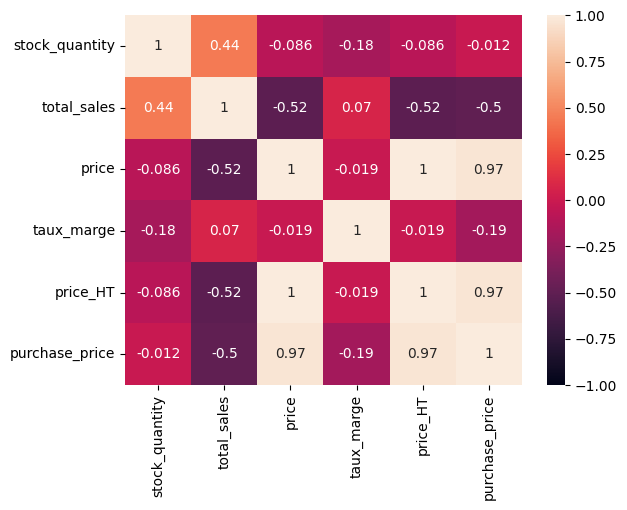

In [129]:
############################
# Analyse des correlations #
############################

#Importation de Seaborn
import seaborn as sns
#Creation d'un heatmap de correlation avec les variables stock, sales et price
#On peut egalement creer un mask pour n'afficher qu'une demi heatmap
sns.heatmap(df_merge[["stock_quantity", "total_sales", "price", "taux_marge", "price_HT", "purchase_price"]].corr(),vmin=-1,vmax=1, annot=True)
'''Analyse quantitative ici, pas qualitative'''

In [130]:
#Que peut-on conclure des correlations ?
'''Forte correlation entre : le prix et le prix d'achat, le prix et le prix hors-taxe
Correlation moyennement negative entre : le prix et les ventes, le prix hors taxe et les ventes'''

"Forte correlation entre : le prix et le prix d'achat, le prix et le prix hors-taxe\nCorrelation moyennement negative entre : le prix et les ventes, le prix hors taxe et les ventes"

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [131]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette etape peut-être utile pour partager le resultat du dataset obtenu pour le partager avec les equipes
df_merge.to_csv('Dataset_projet6.csv', index=False)